In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, metrics
import numpy as np
import matplotlib.pyplot as plt

print(f"Versión de TensorFlow: {tf.__version__}")

Versión de TensorFlow: 2.20.0


In [9]:
#Versión de keras
print(tf.keras.__version__)

3.13.2


In [10]:
!python --version

Python 3.13.15


In [37]:
!nvidia-smi

Fri Aug 28 20:46:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P0             29W /   70W |     637MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [12]:
print("GPU disponible: ", tf.config.list_physical_devices('GPU'))

GPU disponible:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [13]:
fashion_mnist = tf.keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [15]:
train_images.shape

(60000, 28, 28)

In [16]:
test_images.shape

(10000, 28, 28)

In [17]:
train_labels

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

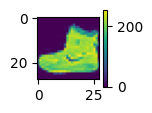

In [22]:
plt.figure(figsize=(1, 1))
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

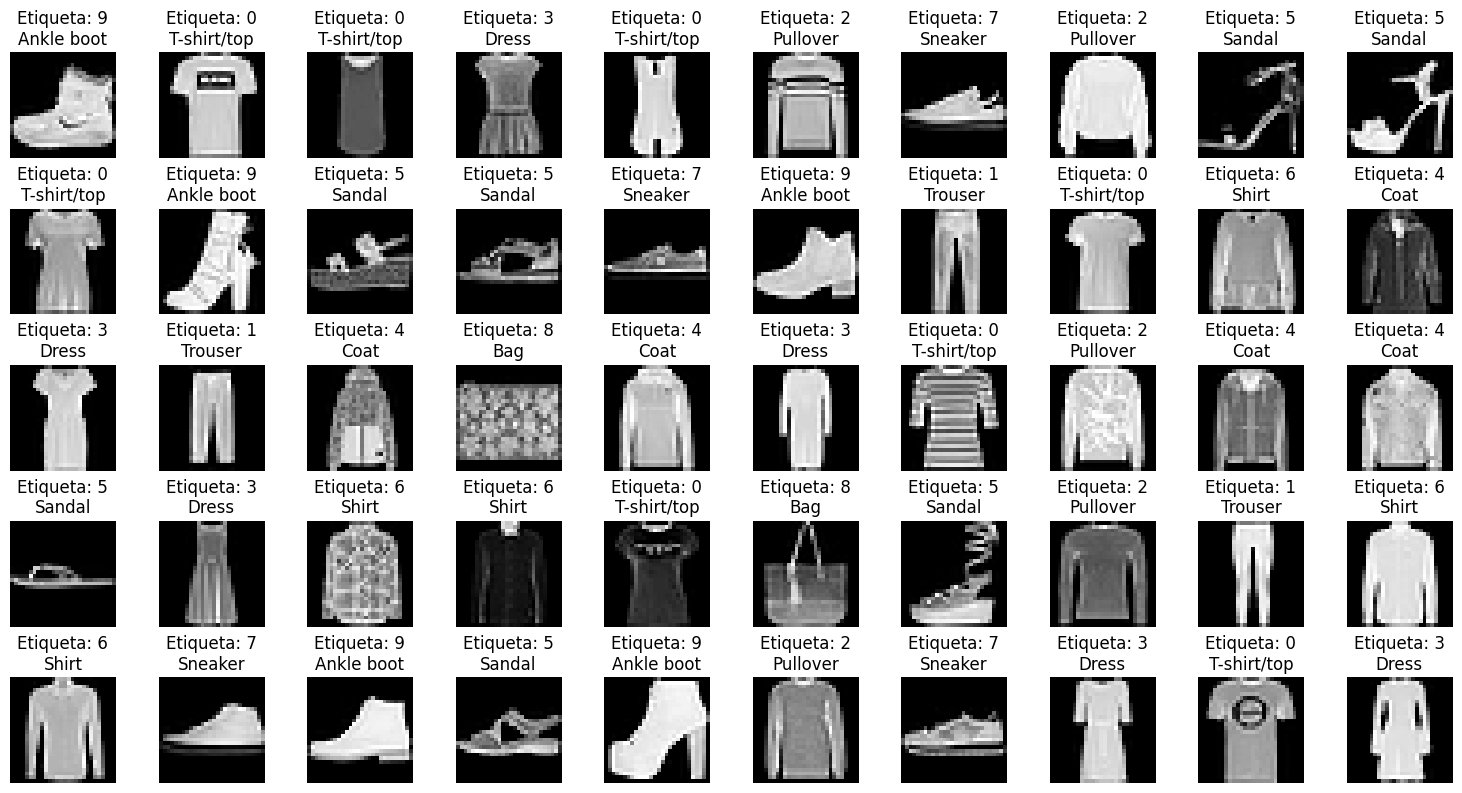

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 10, figsize=(15, 8))

for index, axis in enumerate(axes.flat):
    label = train_labels[index]
    axis.imshow(train_images[index], cmap="gray")
    axis.set_title(f"Etiqueta: {label}\n{class_names[label]}")
    axis.axis("off")

plt.tight_layout()
plt.show()

In [26]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [27]:
train_images[0,:,:]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [34]:
model = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [35]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

In [36]:
model.fit(train_images, train_labels, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7954 - loss: 0.5825
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8594 - loss: 0.3936
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8724 - loss: 0.3557
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8789 - loss: 0.3309
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8853 - loss: 0.3145
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8873 - loss: 0.3023
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8916 - loss: 0.2924
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8952 - loss: 0.2807
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8977 - loss: 0.2749
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9022 - loss: 0.2642


In [38]:
#Guardar el modelo entrenado
model.save('modelo_reconocimiento_prendas.keras')

In [39]:
!pwd

/content


In [40]:
from pathlib import Path
import sys

if "google.colab" in sys.modules:
    from google.colab import drive

    drive.mount("/content/drive")
    ruta_modelo = Path("/content/drive/MyDrive/modelo_reconocimiento_prendas.keras")
    model.save(ruta_modelo)
    print(f"Modelo guardado en Google Drive: {ruta_modelo}")
else:
    print(
        "Este notebook se está ejecutando fuera de Google Colab. "
        "Ejecuta esta celda en Colab para guardar el modelo en Google Drive."
    )

Mounted at /content/drive
Modelo guardado en Google Drive: /content/drive/MyDrive/modelo_reconocimiento_prendas.keras


In [41]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)

print("\nTest accuracy:",test_acc)

313/313 - 2s - 6ms/step - accuracy: 0.8794 - loss: 0.3347

Test accuracy: 0.8794000148773193


In [42]:
predictions = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [43]:
predictions[0]

array([2.6171774e-05, 4.4398189e-06, 1.5286723e-05, 2.0191874e-07,
       6.2995434e-07, 1.9457942e-04, 1.3868265e-05, 2.6962545e-02,
       1.2768681e-04, 9.7265458e-01], dtype=float32)

In [46]:
posicion = np.argmax(predictions[0])

In [45]:
test_labels[0]

np.uint8(9)

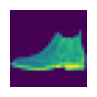

In [47]:
#Mostrar la imagen correspondiente a la predicción de la posición
plt.figure(figsize=(1, 1))
plt.imshow(test_images[0])
plt.axis('off')
plt.show()

In [ ]:
#Extraer de class names el valor de la prediccón
predicted_class = class_names[posicion]
print(f"Predicción: {predicted_class}, Etiqueta real: {class_names[test_labels[0]]}")